# ASAS-SN-Sensitive TDE/ANT Catalog Builder

This notebook is the working implementation for the first-pass TDE/ANT catalog. The catalog-building functions live directly in the cells below so you can inspect and run the workflow step by step.

The path setup cell finds the repo root and changes into it so relative paths like `input/nuclear/tde_catalog.csv` resolve consistently when the notebook is opened from different directories.


## Catalog Code

The next cells define the schema, source loaders, merge logic, data quality guards, and CSV writers used by this notebook. This workflow currently lives here.


### Imports, constants, normalization helpers, date/coordinate utilities, and shared row helpers


In [1]:
"""Build and inspect an ASAS-SN-sensitive TDE/ANT master catalog."""

from __future__ import annotations

import os
import csv
import io
import json
import math
import re
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy.time import Time
import astropy.units as u


# Notebook path setup: make relative input/output paths resolve from the repo root.
def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "malca").exists():
            return candidate
    return start


REPO_ROOT = _find_repo_root(Path.cwd())
os.chdir(REPO_ROOT)
print(f"Using repo root: {REPO_ROOT}")


FINAL_COLUMNS = [
    "tde_id",
    "name",
    "aliases",
    "ra_deg",
    "dec_deg",
    "redshift",
    "discovery_mjd",
    "peak_mjd_ref",
    "discovery_survey",
    "class_label",
    "confidence",
    "host_name",
    "log_mbh",
    "notes",
    "include_flag",
]

RAW_COLUMNS = [
    "source",
    "source_key",
    *FINAL_COLUMNS[:-1],
    "mag_value",
    "mag_band",
    "mag_basis",
    "include_flag",
]

CLASS_LABELS = {
    "tde",
    "tde_candidate",
    "possible_tde",
    "ant",
    "nuclear_transient",
    "rejected_contaminant",
}

CONFIDENCE_LABELS = {"secure", "likely", "possible", "ambiguous", "reject"}

DEFAULT_MAG_LIMIT = 17.5
DEFAULT_ASASSN_TRANSIENTS = Path("input/asassn_transients.csv")
DEFAULT_FINAL_CATALOG = Path("input/nuclear/tde_catalog.csv")
DEFAULT_STAGING_CATALOG = Path("input/nuclear/tde_catalog_staging.csv")

OTTER_CURSOR_URL = "https://otter.idies.jhu.edu/api/_db/otter/_api/cursor"
OTTER_USERNAME = "user-guest"
OTTER_PASSWORD = "test"
MANYTDE_SOURCES_URL = "https://api.github.com/repos/sjoertvv/manyTDE/contents/data/sources"

TDE_CLASS_RE = re.compile(r"\b(tde|tidal disruption|ant|nuclear transient)\b", re.I)
LOCAL_SEED_RE = re.compile(r"\b(tde|tidal|nuclear)\b", re.I)
OBVIOUS_REJECT_RE = re.compile(
    r"\b(type\s+ia|type\s+ii|type\s+ib|type\s+ic|supernova|cv candidate|known sn candidate)\b",
    re.I,
)
MIXED_TDE_RE = re.compile(r"\b(possible|potential|could be|candidate)\b.*\b(tde|nuclear)\b|\b(tde|nuclear)\b.*\b(possible|potential|could be|candidate)\b", re.I)

ASASSN_LIKE_FILTERS = {
    "g",
    "gp",
    "g-band",
    "sdssg",
    "ps1g",
    "ztfg",
    "v",
    "v-band",
    "johnsonv",
    "r",
    "rp",
    "r-band",
    "sdssr",
    "ps1r",
    "ztfr",
    "clear",
    "c",
    "unfiltered",
    "orange",
    "cyan",
}


def _safe_float(value: object) -> float:
    try:
        if value is None or pd.isna(value):
            return np.nan
    except Exception:
        if value is None:
            return np.nan
    text = str(value).strip()
    if not text:
        return np.nan
    m = re.search(r"[-+]?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?", text)
    if not m:
        return np.nan
    try:
        return float(m.group(0))
    except ValueError:
        return np.nan


def _first_finite(values: Iterable[object]) -> float:
    for value in values:
        out = _safe_float(value)
        if np.isfinite(out):
            return float(out)
    return np.nan


def _clean_text(value: object) -> str:
    try:
        if value is None or pd.isna(value):
            return ""
    except Exception:
        if value is None:
            return ""
    text = str(value).strip()
    return "" if text.lower() in {"nan", "none", "null", "-"} else text


def _normalize_bool(value: object) -> bool:
    if isinstance(value, bool):
        return value
    text = _clean_text(value).lower()
    return text in {"1", "true", "t", "yes", "y"}


def _as_list(value: object) -> list[object]:
    if value is None:
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, tuple):
        return list(value)
    return [value]


def alias_key(value: object) -> str:
    """Normalize a transient alias for duplicate matching."""
    text = _clean_text(value).lower()
    text = re.sub(r"[\s_=-]+", "", text)
    text = re.sub(r"[^a-z0-9+.-]", "", text)
    if text.startswith("at") and re.match(r"at\d{4}[a-z]+$", text):
        return text
    if re.match(r"\d{4}[a-z]+$", text):
        return f"at{text}"
    return text


def slug_from_name(value: object) -> str:
    key = alias_key(value)
    return re.sub(r"[^a-z0-9]+", "_", key).strip("_") or "unknown"


def _unique_aliases(values: Iterable[object]) -> list[str]:
    out: list[str] = []
    seen: set[str] = set()
    for raw in values:
        text = _clean_text(raw)
        if not text:
            continue
        key = alias_key(text)
        if not key or key in seen:
            continue
        seen.add(key)
        out.append(text)
    return out


def split_aliases(value: object) -> list[str]:
    text = _clean_text(value)
    if not text:
        return []
    parts = re.split(r"\s*;\s*|\s*,\s*|\s*\(=\s*|\)\s*\(=|\(|\)", text)
    return _unique_aliases(part for part in parts if _clean_text(part))


def preferred_name(default_name: object, aliases: Iterable[object]) -> str:
    alias_list = _unique_aliases([default_name, *aliases])
    for alias in alias_list:
        key = alias_key(alias)
        if re.match(r"at\d{4}[a-z]+$", key):
            m = re.match(r"at(\d{4}[a-z]+)$", key)
            return f"AT {m.group(1)}" if m else alias
    for alias in alias_list:
        if alias.upper().startswith("ASASSN"):
            return alias
    return alias_list[0] if alias_list else "unknown"


def infer_discovery_survey(name: object, aliases: Iterable[object]) -> str:
    text = " ".join(_unique_aliases([name, *aliases])).lower()
    rules = [
        ("ASAS-SN", ("asassn", "asas-sn")),
        ("ZTF", ("ztf",)),
        ("ATLAS", ("atlas",)),
        ("GOTO", ("goto",)),
        ("Gaia", ("gaia",)),
        ("Pan-STARRS", ("ps1", "pan-starrs")),
        ("PTF", ("iptf", "ptf")),
        ("Swift", ("swift", "sw ")),
        ("eROSITA", ("erasst", "srge")),
        ("TNS", ("at ", "at20", "at19", "at18")),
    ]
    for label, needles in rules:
        if any(needle in text for needle in needles):
            return label
    return ""


def parse_mjd(value: object, date_format: object | None = None) -> float:
    text = _clean_text(value)
    if not text:
        return np.nan
    fmt = _clean_text(date_format).lower()
    number = _safe_float(text)
    if fmt == "mjd" and np.isfinite(number):
        return float(number)
    if fmt == "jd" and np.isfinite(number):
        return float(number - 2400000.5)
    if not fmt and np.isfinite(number):
        if number > 2_400_000:
            return float(number - 2400000.5)
        if number > 10_000:
            return float(number)
    try:
        if re.match(r"^\d{4}-\d{1,2}-\d{1,2}(?:\.\d+)?$", text):
            year, month, day = text.split("-")
            day_float = float(day)
            day_int = int(math.floor(day_float))
            frac = day_float - day_int
            iso = f"{int(year):04d}-{int(month):02d}-{day_int:02d}"
            return float(Time(iso, format="iso").mjd + frac)
        return float(Time(text, format="iso").mjd)
    except Exception:
        return np.nan


def _coord_to_deg(ra: object, dec: object, ra_units: object = "deg", dec_units: object = "deg") -> tuple[float, float]:
    ra_text = _clean_text(ra)
    dec_text = _clean_text(dec)
    if not ra_text or not dec_text:
        return np.nan, np.nan
    ra_unit_text = _clean_text(ra_units).lower()
    dec_unit_text = _clean_text(dec_units).lower()
    try:
        if "hour" in ra_unit_text or re.search(r"[:h]", ra_text):
            coord = SkyCoord(ra_text, dec_text, unit=(u.hourangle, u.deg), frame="icrs")
        else:
            coord = SkyCoord(float(ra_text) * u.deg, float(dec_text) * u.deg, frame="icrs")
        return float(coord.ra.deg), float(coord.dec.deg)
    except Exception:
        return _safe_float(ra), _safe_float(dec)


def normalize_class(text: object, *, explicit_class: object = "") -> tuple[str, str]:
    combined = f"{_clean_text(explicit_class)} {_clean_text(text)}".strip()
    lowered = combined.lower()
    if not combined:
        return "nuclear_transient", "ambiguous"
    if "ant" in lowered and "candidate" not in lowered:
        return "ant", "likely"
    if "tidal disruption" in lowered or re.search(r"\btde\b", lowered):
        if "candidate" in lowered or "possible" in lowered or "potential" in lowered:
            return "tde_candidate", "likely"
        return "tde", "secure"
    if "nuclear" in lowered:
        if OBVIOUS_REJECT_RE.search(combined) and not TDE_CLASS_RE.search(combined):
            return "rejected_contaminant", "reject"
        if MIXED_TDE_RE.search(combined):
            return "possible_tde", "possible"
        return "nuclear_transient", "ambiguous"
    if OBVIOUS_REJECT_RE.search(combined):
        return "rejected_contaminant", "reject"
    return "possible_tde", "possible"


def _note_join(*parts: object) -> str:
    out = []
    for part in parts:
        text = _clean_text(part)
        if text:
            out.append(text)
    return "; ".join(out)


def _row(
    *,
    source: str,
    source_key: str,
    name: str,
    aliases: Iterable[object] = (),
    ra_deg: object = np.nan,
    dec_deg: object = np.nan,
    redshift: object = np.nan,
    discovery_mjd: object = np.nan,
    peak_mjd_ref: object = np.nan,
    discovery_survey: str = "",
    class_label: str = "possible_tde",
    confidence: str = "possible",
    host_name: str = "",
    log_mbh: object = np.nan,
    notes: str = "",
    mag_value: object = np.nan,
    mag_band: str = "",
    mag_basis: str = "",
    mag_limit: float = DEFAULT_MAG_LIMIT,
) -> dict[str, object]:
    alias_list = _unique_aliases([name, *aliases])
    preferred = preferred_name(name, alias_list)
    if preferred not in alias_list:
        alias_list.insert(0, preferred)
    mag = _safe_float(mag_value)
    included = bool(
        np.isfinite(mag)
        and mag <= float(mag_limit)
        and class_label != "rejected_contaminant"
    )
    note = notes
    if np.isfinite(mag) and mag_basis:
        note = _note_join(note, f"mag_basis={mag_basis}", f"mag_value={mag:.3f}", f"mag_band={mag_band}")
    elif mag_basis:
        note = _note_join(note, f"mag_basis={mag_basis}")
    return {
        "source": source,
        "source_key": source_key,
        "tde_id": slug_from_name(preferred),
        "name": preferred,
        "aliases": ";".join(alias_list),
        "ra_deg": _safe_float(ra_deg),
        "dec_deg": _safe_float(dec_deg),
        "redshift": _safe_float(redshift),
        "discovery_mjd": _safe_float(discovery_mjd),
        "peak_mjd_ref": _safe_float(peak_mjd_ref),
        "discovery_survey": discovery_survey or infer_discovery_survey(preferred, alias_list),
        "class_label": class_label,
        "confidence": confidence,
        "host_name": host_name,
        "log_mbh": _safe_float(log_mbh),
        "notes": note,
        "mag_value": mag,
        "mag_band": mag_band,
        "mag_basis": mag_basis,
        "include_flag": included,
    }


def _flatten_parallel(block: dict, *keys: str) -> list[dict[str, object]]:
    values: dict[str, list[object]] = {key: _as_list(block.get(key)) for key in keys}
    max_len = max((len(v) for v in values.values()), default=0)
    rows = []
    for idx in range(max_len):
        item = {}
        for key, vals in values.items():
            if not vals:
                item[key] = None
            elif len(vals) == 1:
                item[key] = vals[0]
            else:
                item[key] = vals[idx] if idx < len(vals) else None
        rows.append(item)
    return rows


def _is_asassn_like_filter(filter_name: object) -> bool:
    text = _clean_text(filter_name).lower()
    key = re.sub(r"[^a-z0-9]+", "", text)
    if not key:
        return False
    if key in ASASSN_LIKE_FILTERS:
        return True
    if key.startswith("ztf") and key[-1:] in {"g", "r"}:
        return True
    if key.startswith("ps1") and key[-1:] in {"g", "r"}:
        return True
    if key in {"sdssg", "sdssr", "uvotv"}:
        return True
    return text in ASASSN_LIKE_FILTERS


def _extract_otter_peak_mag(transient: dict) -> tuple[float, str, str]:
    best_mag = np.nan
    best_band = ""
    best_ref = ""
    for block in _as_list(transient.get("photometry")):
        if not isinstance(block, dict):
            continue
        obs_type = _clean_text(block.get("obs_type")).lower()
        if obs_type and "uvoir" not in obs_type and obs_type not in {"optical", "uv", "uv/optical"}:
            continue
        for item in _flatten_parallel(
            block,
            "raw",
            "raw_units",
            "value",
            "value_units",
            "filter_key",
            "filter_name",
            "upperlimit",
            "reference",
        ):
            if _normalize_bool(item.get("upperlimit")):
                continue
            filt = item.get("filter_name") or item.get("filter_key")
            if not _is_asassn_like_filter(filt):
                continue
            units = _clean_text(item.get("raw_units") or item.get("value_units")).lower()
            value = item.get("raw") if "mag" in units else item.get("value")
            if "mag" not in units and "mag" not in _clean_text(item.get("value_units")).lower():
                continue
            mag = _safe_float(value)
            if np.isfinite(mag) and (not np.isfinite(best_mag) or mag < best_mag):
                best_mag = float(mag)
                best_band = _clean_text(filt)
                best_ref = _clean_text(item.get("reference"))
    basis = "OTTER optical photometry"
    if best_ref:
        basis = f"{basis} ({best_ref})"
    return best_mag, best_band, basis


def _extract_manytde_peak_mag(payload: dict) -> tuple[float, str, str]:
    lc = payload.get("lightcurve")
    if not isinstance(lc, dict):
        return np.nan, "", "manyTDE lightcurve"
    header = list(lc.get("header") or [])
    data = list(lc.get("data") or [])
    best_mag = np.nan
    best_band = ""
    if not header or not data:
        return np.nan, "", "manyTDE lightcurve"
    lower_header = [str(col).lower() for col in header]
    try:
        filter_idx = lower_header.index("filter")
    except ValueError:
        filter_idx = 1 if len(header) > 1 else -1
    flux_idx = None
    for needle in ("flux_jy", "flux"):
        if needle in lower_header:
            flux_idx = lower_header.index(needle)
            break
    if flux_idx is None:
        flux_idx = 2 if len(header) > 2 else -1
    for values in data:
        if not isinstance(values, list) or flux_idx < 0 or flux_idx >= len(values):
            continue
        filt = values[filter_idx] if 0 <= filter_idx < len(values) else ""
        if not _is_asassn_like_filter(filt):
            continue
        flux_jy = _safe_float(values[flux_idx])
        if not np.isfinite(flux_jy) or flux_jy <= 0:
            continue
        mag = -2.5 * math.log10(flux_jy / 3631.0)
        if np.isfinite(mag) and (not np.isfinite(best_mag) or mag < best_mag):
            best_mag = float(mag)
            best_band = _clean_text(filt)
    return best_mag, best_band, "manyTDE flux_Jy AB approximation"




Using repo root: /Users/calder/code/malca


### Local ASAS-SN transient seed loader plus OTTER helper extractors


In [2]:
def rows_from_asassn_transients(
    path: str | Path = DEFAULT_ASASSN_TRANSIENTS,
    *,
    mag_limit: float = DEFAULT_MAG_LIMIT,
) -> pd.DataFrame:
    in_path = Path(path)
    if not in_path.exists():
        return pd.DataFrame(columns=RAW_COLUMNS)
    df = pd.read_csv(in_path)
    rows: list[dict[str, object]] = []
    for idx, src in df.iterrows():
        comment = _clean_text(src.get("comments"))
        spectral_class = _clean_text(src.get("spectroscopic_class"))
        if not LOCAL_SEED_RE.search(f"{comment} {spectral_class}"):
            continue
        label, confidence = normalize_class(comment, explicit_class=spectral_class)
        aliases = split_aliases(src.get("other_ids"))
        asassn = _clean_text(src.get("asassn_id"))
        if asassn:
            aliases.append(asassn)
        name = preferred_name(asassn or src.get("other_ids") or f"asassn-row-{idx}", aliases)
        discovery_mjd = parse_mjd(src.get("discovery_ut"))
        rows.append(
            _row(
                source="asassn_transients",
                source_key=str(idx),
                name=name,
                aliases=aliases,
                ra_deg=src.get("ra_deg"),
                dec_deg=src.get("dec_deg"),
                redshift=_redshift_from_text(comment),
                discovery_mjd=discovery_mjd,
                discovery_survey="ASAS-SN" if asassn else infer_discovery_survey(name, aliases),
                class_label=label,
                confidence=confidence,
                notes=_note_join("source=input/asassn_transients.csv", comment),
                mag_value=src.get("v_g_mag"),
                mag_band="ASAS-SN V/g",
                mag_basis="ASAS-SN v_g_mag",
                mag_limit=mag_limit,
            )
        )
    return pd.DataFrame(rows, columns=RAW_COLUMNS)


def _redshift_from_text(text: object) -> float:
    match = re.search(r"\bz\s*[=:]\s*([0-9.]+)", _clean_text(text), flags=re.I)
    return float(match.group(1)) if match else np.nan


def _default_entry(entries: object) -> dict:
    items = [entry for entry in _as_list(entries) if isinstance(entry, dict)]
    if not items:
        return {}
    for entry in items:
        if _normalize_bool(entry.get("default")):
            return entry
    return items[0]


def _otter_aliases(transient: dict) -> list[str]:
    name = transient.get("name") or {}
    aliases = [_clean_text(name.get("default_name"))]
    for entry in _as_list(name.get("alias")):
        if isinstance(entry, dict):
            aliases.append(entry.get("value"))
    return _unique_aliases(aliases)


def _otter_class_text(transient: dict) -> str:
    classification = transient.get("classification") or {}
    classes = []
    for entry in _as_list(classification.get("value")):
        if isinstance(entry, dict):
            classes.append(_clean_text(entry.get("object_class")))
    return " ".join(classes)


def _otter_class_label(transient: dict) -> tuple[str, str]:
    classification = transient.get("classification") or {}
    class_text = _otter_class_text(transient)
    label, confidence = normalize_class(class_text)
    if label == "tde":
        unambiguous = _normalize_bool(classification.get("unambiguous"))
        spec = _safe_float(classification.get("spec_classed"))
        max_conf = max(
            [_safe_float(entry.get("confidence")) for entry in _as_list(classification.get("value")) if isinstance(entry, dict)]
            or [np.nan]
        )
        if unambiguous or (np.isfinite(spec) and spec > 0) or (np.isfinite(max_conf) and max_conf >= 1):
            return "tde", "secure"
        return "tde_candidate", "likely"
    return label, confidence


def _otter_dates(transient: dict) -> tuple[float, float]:
    discovery = np.nan
    peak = np.nan
    for entry in _as_list(transient.get("date_reference")):
        if not isinstance(entry, dict):
            continue
        mjd = parse_mjd(entry.get("value"), entry.get("date_format"))
        if not np.isfinite(mjd):
            continue
        kind = _clean_text(entry.get("date_type")).lower()
        if "peak" in kind and (not np.isfinite(peak) or _normalize_bool(entry.get("default"))):
            peak = mjd
        if "discover" in kind and (not np.isfinite(discovery) or _normalize_bool(entry.get("default"))):
            discovery = mjd
    return discovery, peak




### OTTER REST source loader


In [3]:
def rows_from_otter(
    *,
    mag_limit: float = DEFAULT_MAG_LIMIT,
    cursor_url: str = OTTER_CURSOR_URL,
    username: str = OTTER_USERNAME,
    password: str = OTTER_PASSWORD,
    timeout: float = 60.0,
) -> pd.DataFrame:
    import requests

    query = (
        "FOR t IN transients "
        "FILTER t.classification != null "
        "FILTER LENGTH(FOR c IN t.classification.value "
        "FILTER CONTAINS(LOWER(c.object_class), 'tde') "
        "OR CONTAINS(LOWER(c.object_class), 'tidal') "
        "OR CONTAINS(LOWER(c.object_class), 'nuclear') "
        "OR CONTAINS(LOWER(c.object_class), 'ant') RETURN 1) > 0 "
        "RETURN t"
    )
    response = requests.post(
        cursor_url,
        auth=(username, password),
        headers={"accept": "application/json", "Content-Type": "application/json"},
        json={"query": query, "count": True, "batchSize": 100},
        timeout=timeout,
    )
    response.raise_for_status()
    payload = response.json()
    results = list(payload.get("result") or [])
    cursor_id = payload.get("id")
    while payload.get("hasMore") and cursor_id:
        response = requests.put(
            f"{cursor_url}/{cursor_id}",
            auth=(username, password),
            headers={"accept": "application/json"},
            timeout=timeout,
        )
        response.raise_for_status()
        payload = response.json()
        results.extend(payload.get("result") or [])
        cursor_id = payload.get("id") or cursor_id

    rows: list[dict[str, object]] = []
    for transient in results:
        aliases = _otter_aliases(transient)
        if not aliases:
            continue
        coord = _default_entry(transient.get("coordinate"))
        ra_deg, dec_deg = _coord_to_deg(coord.get("ra"), coord.get("dec"), coord.get("ra_units"), coord.get("dec_units"))
        distance = _default_entry(
            [entry for entry in _as_list(transient.get("distance")) if isinstance(entry, dict) and "redshift" in _clean_text(entry.get("distance_type")).lower()]
        )
        host = _default_entry(transient.get("host"))
        discovery, peak = _otter_dates(transient)
        mag, band, basis = _extract_otter_peak_mag(transient)
        label, confidence = _otter_class_label(transient)
        rows.append(
            _row(
                source="otter",
                source_key=_clean_text(transient.get("_key")),
                name=preferred_name((transient.get("name") or {}).get("default_name"), aliases),
                aliases=aliases,
                ra_deg=ra_deg,
                dec_deg=dec_deg,
                redshift=distance.get("value"),
                discovery_mjd=discovery,
                peak_mjd_ref=peak,
                discovery_survey=_clean_text((transient.get("classification") or {}).get("discovery_method")),
                class_label=label,
                confidence=confidence,
                host_name=_clean_text(host.get("host_name") or host.get("name")),
                notes=_note_join("source=OTTER", _otter_class_text(transient)),
                mag_value=mag,
                mag_band=band,
                mag_basis=basis,
                mag_limit=mag_limit,
            )
        )
    return pd.DataFrame(rows, columns=RAW_COLUMNS)




### manyTDE GitHub source loader


In [4]:
def rows_from_manytde(
    *,
    mag_limit: float = DEFAULT_MAG_LIMIT,
    sources_url: str = MANYTDE_SOURCES_URL,
    timeout: float = 60.0,
    max_sources: int | None = None,
) -> pd.DataFrame:
    import requests

    listing = requests.get(sources_url, timeout=timeout)
    listing.raise_for_status()
    files = [item for item in listing.json() if str(item.get("name", "")).endswith(".json")]
    if max_sources is not None:
        files = files[: int(max_sources)]
    rows: list[dict[str, object]] = []
    for item in files:
        url = item.get("download_url")
        if not url:
            continue
        response = requests.get(url, timeout=timeout)
        response.raise_for_status()
        try:
            payload = response.json()
        except ValueError:
            continue
        if not isinstance(payload, dict):
            continue
        aliases = _unique_aliases([payload.get("name"), payload.get("nickname")])
        mag, band, basis = _extract_manytde_peak_mag(payload)
        label, confidence = normalize_class(payload.get("spectral_type"), explicit_class="TDE")
        rows.append(
            _row(
                source="manyTDE",
                source_key=item.get("name", ""),
                name=payload.get("name", ""),
                aliases=aliases,
                ra_deg=payload.get("ra"),
                dec_deg=payload.get("dec"),
                redshift=payload.get("z"),
                peak_mjd_ref=payload.get("peak_mjd"),
                discovery_survey=infer_discovery_survey(payload.get("name"), aliases),
                class_label=label,
                confidence=confidence,
                host_name=_clean_text((payload.get("host") or {}).get("name")),
                notes=_note_join("source=manyTDE", f"spectral_type={_clean_text(payload.get('spectral_type'))}", f"paper_ref={_clean_text(payload.get('paper_ref'))}"),
                mag_value=mag,
                mag_band=band,
                mag_basis=basis,
                mag_limit=mag_limit,
            )
        )
    return pd.DataFrame(rows, columns=RAW_COLUMNS)




### Optional TNS CSV/TSV source loader


In [5]:
def rows_from_tns_csv(
    path: str | Path,
    *,
    mag_limit: float = DEFAULT_MAG_LIMIT,
) -> pd.DataFrame:
    in_path = Path(path)
    if not in_path.exists():
        return pd.DataFrame(columns=RAW_COLUMNS)
    sep = "\t" if in_path.suffix.lower() in {".tsv", ".txt"} else ","
    df = pd.read_csv(in_path, sep=sep)
    rows: list[dict[str, object]] = []
    lower_cols = {str(col).lower(): col for col in df.columns}

    def col(*names: str) -> str | None:
        for name in names:
            key = name.lower()
            if key in lower_cols:
                return lower_cols[key]
        return None

    for idx, src in df.iterrows():
        class_text = " ".join(_clean_text(src.get(c)) for c in df.columns if "type" in str(c).lower() or "class" in str(c).lower())
        if not LOCAL_SEED_RE.search(class_text):
            continue
        label, confidence = normalize_class(class_text)
        name = _clean_text(src.get(col("Name", "Obj. Name", "Object Name", "objname") or ""))
        aliases = split_aliases(src.get(col("Internal Name", "Disc. Internal Name", "aliases") or ""))
        rows.append(
            _row(
                source="tns_csv",
                source_key=str(idx),
                name=name or f"tns-row-{idx}",
                aliases=aliases,
                ra_deg=src.get(col("RA", "TNS RA", "ra") or ""),
                dec_deg=src.get(col("DEC", "TNS DEC", "dec") or ""),
                redshift=src.get(col("Redshift", "Host Redshift", "TNS Redshift") or ""),
                discovery_mjd=parse_mjd(src.get(col("Discovery Date", "Disc. Date") or "")),
                discovery_survey=_clean_text(src.get(col("Discovery Data Source", "Disc. Data Source", "Discovery Survey") or "")),
                class_label=label,
                confidence=confidence,
                host_name=_clean_text(src.get(col("Host Name", "host") or "")),
                notes=_note_join("source=TNS CSV", class_text),
                mag_value=src.get(col("Discovery Mag", "Disc. Mag", "Mag") or ""),
                mag_band=_clean_text(src.get(col("Discovery Filter", "Filter", "Band") or "")),
                mag_basis="TNS discovery_mag",
                mag_limit=mag_limit,
            )
        )
    return pd.DataFrame(rows, columns=RAW_COLUMNS)




### Deduplication, merge, and final-catalog construction


In [6]:
def _source_priority(source: str) -> int:
    return {"otter": 0, "tns_csv": 1, "manyTDE": 2, "asassn_transients": 3}.get(source, 9)


def _row_alias_keys(row: pd.Series) -> set[str]:
    return {alias_key(alias) for alias in split_aliases(row.get("aliases")) + [_clean_text(row.get("name"))] if alias_key(alias)}


def _merge_group(rows: list[pd.Series], *, mag_limit: float = DEFAULT_MAG_LIMIT) -> dict[str, object]:
    ordered = sorted(rows, key=lambda row: (_source_priority(_clean_text(row.get("source"))), _clean_text(row.get("name"))))
    aliases = _unique_aliases(alias for row in ordered for alias in split_aliases(row.get("aliases")) + [_clean_text(row.get("name"))])
    base = ordered[0].copy()
    for col in ("ra_deg", "dec_deg", "redshift", "discovery_mjd", "peak_mjd_ref", "log_mbh"):
        base[col] = _first_finite(row.get(col) for row in ordered)
    for col in ("host_name", "discovery_survey"):
        base[col] = next((_clean_text(row.get(col)) for row in ordered if _clean_text(row.get(col))), "")
    class_rows = sorted(ordered, key=lambda row: ["secure", "likely", "possible", "ambiguous", "reject"].index(_clean_text(row.get("confidence")) if _clean_text(row.get("confidence")) in CONFIDENCE_LABELS else "ambiguous"))
    base["class_label"] = class_rows[0].get("class_label")
    base["confidence"] = class_rows[0].get("confidence")

    mag_rows = [
        row for row in ordered
        if np.isfinite(_safe_float(row.get("mag_value")))
    ]
    if mag_rows:
        mag_row = min(mag_rows, key=lambda row: _safe_float(row.get("mag_value")))
        base["mag_value"] = _safe_float(mag_row.get("mag_value"))
        base["mag_band"] = _clean_text(mag_row.get("mag_band"))
        base["mag_basis"] = _clean_text(mag_row.get("mag_basis"))
    else:
        base["mag_value"] = np.nan
        base["mag_band"] = ""
        base["mag_basis"] = ""

    base["name"] = preferred_name(base.get("name"), aliases)
    if base["name"] not in aliases:
        aliases.insert(0, base["name"])
    base["aliases"] = ";".join(_unique_aliases(aliases))
    base["tde_id"] = slug_from_name(base["name"])
    source_notes = [f"sources={','.join(sorted({_clean_text(row.get('source')) for row in ordered if _clean_text(row.get('source'))}))}"]
    source_notes.extend(_clean_text(row.get("notes")) for row in ordered if _clean_text(row.get("notes")))
    base["notes"] = _note_join(*source_notes)
    if np.isfinite(_safe_float(base.get("mag_value"))) and _clean_text(base.get("mag_basis")) and "mag_basis=" not in base["notes"]:
        base["notes"] = _note_join(
            base["notes"],
            f"mag_basis={base['mag_basis']}",
            f"mag_value={_safe_float(base['mag_value']):.3f}",
            f"mag_band={_clean_text(base.get('mag_band'))}",
        )
    base["include_flag"] = bool(
        np.isfinite(_safe_float(base.get("mag_value")))
        and _safe_float(base.get("mag_value")) <= float(mag_limit)
        and base.get("class_label") != "rejected_contaminant"
    )
    return {col: base.get(col, "") for col in RAW_COLUMNS}


def build_master_catalog(
    raw_rows: pd.DataFrame,
    *,
    mag_limit: float = DEFAULT_MAG_LIMIT,
) -> pd.DataFrame:
    if raw_rows is None or raw_rows.empty:
        return pd.DataFrame(columns=FINAL_COLUMNS)
    rows = [row for _, row in raw_rows.iterrows()]
    groups: list[list[pd.Series]] = []
    group_keys: list[set[str]] = []
    for row in rows:
        keys = _row_alias_keys(row)
        hit_idx = None
        for idx, existing in enumerate(group_keys):
            if keys & existing:
                hit_idx = idx
                break
        if hit_idx is None:
            groups.append([row])
            group_keys.append(set(keys))
        else:
            groups[hit_idx].append(row)
            group_keys[hit_idx].update(keys)

    merged = [_merge_group(group, mag_limit=mag_limit) for group in groups]
    out = pd.DataFrame(merged)
    if out.empty:
        return pd.DataFrame(columns=FINAL_COLUMNS)
    out = out.sort_values(["include_flag", "name"], ascending=[False, True]).reset_index(drop=True)
    final = out[FINAL_COLUMNS].copy()
    final["include_flag"] = final["include_flag"].astype(bool)
    return final




### Validation, source orchestration, and CSV writing


In [7]:
def validate_tde_catalog(df: pd.DataFrame) -> None:
    if list(df.columns) != FINAL_COLUMNS:
        raise ValueError(f"TDE catalog columns must be exactly {FINAL_COLUMNS}; got {list(df.columns)}")
    if df["tde_id"].astype(str).str.strip().eq("").any():
        raise ValueError("TDE catalog has empty tde_id values")
    dup_ids = df["tde_id"][df["tde_id"].duplicated()].tolist()
    if dup_ids:
        raise ValueError(f"Duplicate tde_id values: {dup_ids}")
    ra = pd.to_numeric(df["ra_deg"], errors="coerce")
    dec = pd.to_numeric(df["dec_deg"], errors="coerce")
    bad_coord = ~(ra.between(0, 360, inclusive="left") & dec.between(-90, 90, inclusive="both"))
    if bad_coord.any():
        raise ValueError(f"Invalid coordinates for rows: {df.loc[bad_coord, 'tde_id'].tolist()}")
    bad_class = sorted(set(df["class_label"].astype(str)) - CLASS_LABELS)
    if bad_class:
        raise ValueError(f"Invalid class_label values: {bad_class}")
    bad_conf = sorted(set(df["confidence"].astype(str)) - CONFIDENCE_LABELS)
    if bad_conf:
        raise ValueError(f"Invalid confidence values: {bad_conf}")
    rejected_true = (df["class_label"] == "rejected_contaminant") & df["include_flag"].astype(bool)
    if rejected_true.any():
        raise ValueError(f"Rejected contaminants cannot have include_flag=true: {df.loc[rejected_true, 'tde_id'].tolist()}")
    included = df[df["include_flag"].astype(bool)]
    missing_mag_note = ~included["notes"].astype(str).str.contains(r"mag_basis=.*mag_value=", regex=True, na=False)
    if missing_mag_note.any():
        raise ValueError(f"Included rows missing magnitude provenance: {included.loc[missing_mag_note, 'tde_id'].tolist()}")
    bad_mag = []
    for _, row in included.iterrows():
        match = re.search(r"mag_value=([0-9.]+)", str(row["notes"]))
        if not match or float(match.group(1)) > DEFAULT_MAG_LIMIT:
            bad_mag.append(row["tde_id"])
    if bad_mag:
        raise ValueError(f"Included rows exceed magnitude limit or lack parseable mag_value: {bad_mag}")
    owner: dict[str, str] = {}
    collisions: list[tuple[str, str, str]] = []
    for _, row in df.iterrows():
        for alias in split_aliases(row["aliases"]) + [row["name"]]:
            key = alias_key(alias)
            if not key:
                continue
            prev = owner.get(key)
            if prev is not None and prev != row["tde_id"]:
                collisions.append((key, prev, row["tde_id"]))
            owner[key] = row["tde_id"]
    if collisions:
        raise ValueError(f"Alias collisions across catalog rows: {collisions[:10]}")


def build_catalog_from_sources(
    *,
    asassn_transients: str | Path | None = DEFAULT_ASASSN_TRANSIENTS,
    tns_csv: str | Path | None = None,
    include_otter: bool = True,
    include_manytde: bool = True,
    mag_limit: float = DEFAULT_MAG_LIMIT,
    max_manytde_sources: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    frames: list[pd.DataFrame] = []
    if include_otter:
        frames.append(rows_from_otter(mag_limit=mag_limit))
    if include_manytde:
        frames.append(rows_from_manytde(mag_limit=mag_limit, max_sources=max_manytde_sources))
    if tns_csv:
        frames.append(rows_from_tns_csv(tns_csv, mag_limit=mag_limit))
    if asassn_transients:
        frames.append(rows_from_asassn_transients(asassn_transients, mag_limit=mag_limit))
    frames = [frame for frame in frames if frame is not None and not frame.empty]
    raw = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=RAW_COLUMNS)
    final = build_master_catalog(raw, mag_limit=mag_limit)
    validate_tde_catalog(final)
    return raw, final


def write_catalogs(raw: pd.DataFrame, final: pd.DataFrame, *, staging_path: str | Path, final_path: str | Path) -> None:
    staging = Path(staging_path)
    final_out = Path(final_path)
    staging.parent.mkdir(parents=True, exist_ok=True)
    final_out.parent.mkdir(parents=True, exist_ok=True)
    raw.to_csv(staging, index=False, quoting=csv.QUOTE_MINIMAL)
    final.to_csv(final_out, index=False, quoting=csv.QUOTE_MINIMAL)




## Notebook Run Configuration

Edit these values before running the build cell. By default, this uses OTTER plus manyTDE plus the local ASAS-SN seed table, with an optional TNS CSV path left empty.


In [8]:
MAG_LIMIT = 17.5
ASASSN_TRANSIENTS = Path("input/asassn_transients.csv")
TNS_CSV = None  # Example: Path("input/nuclear/tns_tde_export.csv")
INCLUDE_OTTER = True
INCLUDE_MANYTDE = True
MAX_MANYTDE_SOURCES = None  # Set to a small integer for a quick smoke run.

FINAL_OUTPUT = Path("input/nuclear/tde_catalog.csv")
STAGING_OUTPUT = Path("input/nuclear/tde_catalog_staging.csv")


## Build The Raw Union And Final Catalog

This cell calls the notebook-defined source orchestration directly, then writes both the raw staging table and the final stable-schema catalog.


In [9]:
raw, final = build_catalog_from_sources(
    asassn_transients=ASASSN_TRANSIENTS,
    tns_csv=TNS_CSV,
    include_otter=INCLUDE_OTTER,
    include_manytde=INCLUDE_MANYTDE,
    mag_limit=MAG_LIMIT,
    max_manytde_sources=MAX_MANYTDE_SOURCES,
)

write_catalogs(raw, final, staging_path=STAGING_OUTPUT, final_path=FINAL_OUTPUT)

print(f"Wrote {len(raw):,} staging rows to {STAGING_OUTPUT}")
print(f"Wrote {len(final):,} master rows to {FINAL_OUTPUT}")
print(f"Included {int(final['include_flag'].sum()):,} rows with catalog optical magnitude <= {MAG_LIMIT:g}")


/opt/homebrew/Caskroom/miniconda/base/envs/malca/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


Wrote 356 staging rows to input/nuclear/tde_catalog_staging.csv
Wrote 257 master rows to input/nuclear/tde_catalog.csv
Included 26 rows with catalog optical magnitude <= 17.5


## Inspect The Results

These cells show source coverage, class balance, included objects, and known bright seed recovery.


In [10]:
source_counts = raw["source"].value_counts(dropna=False).rename_axis("source").reset_index(name="rows")
source_counts


,source,rows
0,otter,242
1,manyTDE,92
2,asassn_transients,22


In [11]:
class_counts = final["class_label"].value_counts(dropna=False).rename_axis("class_label").reset_index(name="rows")
included_class_counts = final.loc[final["include_flag"].astype(bool), "class_label"].value_counts(dropna=False).rename_axis("class_label").reset_index(name="included_rows")

class_counts.merge(included_class_counts, on="class_label", how="left").fillna({"included_rows": 0}).astype({"included_rows": int})


,class_label,rows,included_rows
0,tde,222,11
1,tde_candidate,29,10
2,possible_tde,4,4
3,ant,1,1
4,rejected_contaminant,1,0


In [12]:
included = final.loc[final["include_flag"].astype(bool)].copy()
included[["name", "aliases", "redshift", "class_label", "confidence", "discovery_survey", "notes"]]


,name,aliases,redshift,class_label,confidence,discovery_survey,notes
0,ASASSN-14ae,ASASSN-14ae;iPTF14aiv,0.043671,tde,secure,optical,"sources=asassn_transients,manyTDE,otter; sourc..."
1,ASASSN-14li,ASASSN-14li,0.020600,tde,secure,optical,"sources=asassn_transients,manyTDE,otter; sourc..."
2,ASASSN-15oi,ASASSN-15oi,0.048400,tde,secure,optical,"sources=asassn_transients,otter; source=OTTER;..."
3,AT 2016fnl,AT 2016fnl;iPTF 16fnl,0.016300,tde,secure,optical,"sources=manyTDE,otter; source=OTTER; TDE; mag_..."
4,AT 2017bcc,AT 2017bcc;ZTF20aacbwbm;SN 2017bcc;PS17bgn,0.133000,ant,likely,optical,sources=otter; source=OTTER; TDE ANT SLSN-II; ...
5,AT 2018dyk,AT 2018dyk;ZTF18aajupnt;WTP18aamced,0.036720,tde,secure,optical,sources=otter; source=OTTER; TDE AGN; mag_basi...
6,AT 2019dsg,AT 2019dsg;ATLAS19klx;ZTF19aapreis;BranStark,0.051200,tde,secure,optical,"sources=asassn_transients,manyTDE,otter; sourc..."
7,AT 2019von,AT 2019von;ASASSN-19abt,NaN,possible_tde,possible,ASAS-SN,sources=asassn_transients; source=input/asassn...
8,AT 2020afhd,AT 2020afhd;ZTF20abwtifz;ATLAS24btc,0.024000,tde_candidate,likely,ZTF,sources=asassn_transients; source=input/asassn...
9,AT 2020pom,AT 2020pom;ASASSN-20il,NaN,tde_candidate,likely,ASAS-SN,sources=asassn_transients; source=input/asassn...


In [13]:
known_seed_aliases = [
    "ASASSN-14ae",
    "ASASSN-14li",
    "ASASSN-15oi",
    "ASASSN-18zj",
    "ASASSN-18ul",
    "ASASSN-19bt",
    "AT 2019dsg",
]

identity_text = (final["name"].fillna("") + ";" + final["aliases"].fillna("")).str.lower()
seed_recovery = pd.DataFrame(
    {
        "seed": known_seed_aliases,
        "present": [bool(identity_text.str.contains(seed.lower(), regex=False).any()) for seed in known_seed_aliases],
    }
)
seed_recovery


,seed,present
0,ASASSN-14ae,True
1,ASASSN-14li,True
2,ASASSN-15oi,True
3,ASASSN-18zj,True
4,ASASSN-18ul,True
5,ASASSN-19bt,True
6,AT 2019dsg,True


## Population Science

These cells treat `include_flag=True` as the current ASAS-SN-sensitive working sample. The absolute magnitudes below are quick observed-frame proxies: catalog optical magnitude minus distance modulus, with no K-correction, extinction correction, or host subtraction yet.


In [14]:
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt

COSMO = FlatLambdaCDM(H0=70, Om0=0.3)


def extract_note_field(notes: object, field: str) -> str:
    match = re.search(rf"{field}=([^;]+)", str(notes))
    return match.group(1).strip() if match else ""


def mjd_to_decimal_year(mjd: object) -> float:
    value = _safe_float(mjd)
    if not np.isfinite(value):
        return np.nan
    return float(Time(value, format="mjd").decimalyear)


def distance_modulus_from_redshift(redshift: pd.Series) -> np.ndarray:
    z = pd.to_numeric(redshift, errors="coerce").to_numpy(dtype=float)
    out = np.full(len(z), np.nan)
    mask = np.isfinite(z) & (z > 0)
    if mask.any():
        out[mask] = COSMO.distmod(z[mask]).value
    return out


science = final.copy()
science["include_flag"] = science["include_flag"].astype(bool)
science["ra_deg"] = pd.to_numeric(science["ra_deg"], errors="coerce")
science["dec_deg"] = pd.to_numeric(science["dec_deg"], errors="coerce")
science["redshift"] = pd.to_numeric(science["redshift"], errors="coerce")
science["discovery_mjd"] = pd.to_numeric(science["discovery_mjd"], errors="coerce")
science["peak_mjd_ref"] = pd.to_numeric(science["peak_mjd_ref"], errors="coerce")
science["mag_value"] = science["notes"].map(lambda value: _safe_float(extract_note_field(value, "mag_value")))
science["mag_band"] = science["notes"].map(lambda value: extract_note_field(value, "mag_band"))
science["mag_basis"] = science["notes"].map(lambda value: extract_note_field(value, "mag_basis"))
science["discovery_year"] = science["discovery_mjd"].map(mjd_to_decimal_year)
science["distance_modulus"] = distance_modulus_from_redshift(science["redshift"])
science["abs_mag_proxy"] = science["mag_value"] - science["distance_modulus"]

included_science = science.loc[science["include_flag"]].copy()

summary = pd.DataFrame(
    [
        ("catalog rows", len(science)),
        ("included rows", len(included_science)),
        ("secure included TDEs", int(((included_science["class_label"] == "tde") & (included_science["confidence"] == "secure")).sum())),
        ("candidate/possible included", int(included_science["class_label"].isin(["tde_candidate", "possible_tde", "ant", "nuclear_transient"]).sum())),
        ("median included redshift", included_science["redshift"].median()),
        ("max included redshift", included_science["redshift"].max()),
        ("median catalog optical mag", included_science["mag_value"].median()),
        ("median absolute-mag proxy", included_science["abs_mag_proxy"].median()),
    ],
    columns=["quantity", "value"],
)
summary


,quantity,value
0,catalog rows,257.000000
1,included rows,26.000000
2,secure included TDEs,11.000000
3,candidate/possible included,15.000000
4,median included redshift,0.040196
5,max included redshift,0.147000
6,median catalog optical mag,16.674000
7,median absolute-mag proxy,-19.413021


In [15]:
class_mix = (
    science.groupby(["include_flag", "class_label"], dropna=False)
    .agg(
        n=("tde_id", "size"),
        median_redshift=("redshift", "median"),
        median_catalog_mag=("mag_value", "median"),
    )
    .reset_index()
    .sort_values(["include_flag", "n"], ascending=[False, False])
)
class_mix


,include_flag,class_label,n,median_redshift,median_catalog_mag
5,True,tde,11,0.036360,16.72
6,True,tde_candidate,10,0.050000,16.59
4,True,possible_tde,4,NaN,16.57
3,True,ant,1,0.133000,16.69
1,False,tde,211,0.080500,19.17
2,False,tde_candidate,19,0.187600,17.91
0,False,rejected_contaminant,1,0.022712,16.83


In [16]:
display_columns = [
    "name",
    "aliases",
    "redshift",
    "mag_value",
    "mag_band",
    "abs_mag_proxy",
    "discovery_year",
    "class_label",
    "confidence",
    "mag_basis",
]

included_science[display_columns].sort_values(["class_label", "redshift", "mag_value"], na_position="last")


,name,aliases,redshift,mag_value,mag_band,abs_mag_proxy,discovery_year,class_label,confidence,mag_basis
4,AT 2017bcc,AT 2017bcc;ZTF20aacbwbm;SN 2017bcc;PS17bgn,0.133000,16.690,c,-22.291417,2017.131507,ant,likely,OTTER optical photometry (2024MNRAS.531.1905R)
15,AT 2021hfu,AT 2021hfu;ASASSN-21ek,NaN,15.680,ASAS-SN V/g,NaN,2021.238795,possible_tde,possible,ASAS-SN v_g_mag
17,AT 2021ncq,AT 2021ncq;ASASSN-21iu,NaN,16.360,ASAS-SN V/g,NaN,2021.389452,possible_tde,possible,ASAS-SN v_g_mag
13,AT 2020ybf,AT 2020ybf;ASASSN-20nh,NaN,16.780,ASAS-SN V/g,NaN,2020.801339,possible_tde,possible,ASAS-SN v_g_mag
7,AT 2019von,AT 2019von;ASASSN-19abt,NaN,16.820,ASAS-SN V/g,NaN,2019.888411,possible_tde,possible,ASAS-SN v_g_mag
18,AT 2023clx,AT 2023clx;ZTF18aabkvpi;ASASSN-23bd;AT 20203clx,0.011070,15.370,g,-18.027829,2023.143041,tde,secure,OTTER optical photometry (2024A&A...689A.350C)
3,AT 2016fnl,AT 2016fnl;iPTF 16fnl,0.016300,17.170,g,-17.076655,2016.650273,tde,secure,OTTER optical photometry (2017ApJ...844...46B)
14,AT 2021ehb,AT 2021ehb;ATLAS21jdy;ZTF21aanxhjv;BoKatan,0.017000,17.421,ztf.r,-16.918111,2021.162036,tde,secure,OTTER optical photometry (2023ApJS..266....9A)
1,ASASSN-14li,ASASSN-14li,0.020600,16.668,V,-18.094095,2014.890411,tde,secure,OTTER optical photometry (2016MNRAS.455.2918H)
20,AT 2023lli,AT 2023lli,0.036000,17.273,g,-18.726132,2023.474227,tde,secure,OTTER optical photometry (2024ApJ...964L..22H)


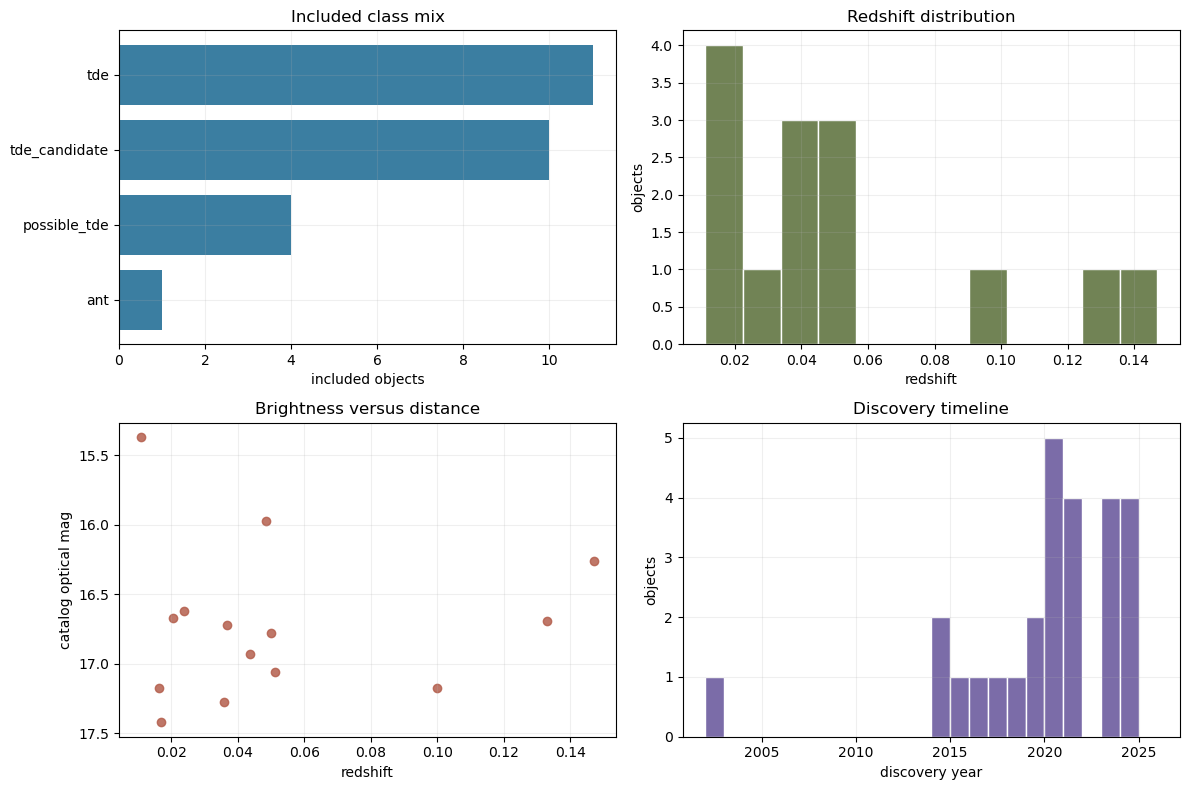

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

class_counts = included_science["class_label"].value_counts().sort_values(ascending=True)
axes[0, 0].barh(class_counts.index, class_counts.values, color="#3b7ea1")
axes[0, 0].set_xlabel("included objects")
axes[0, 0].set_title("Included class mix")

axes[0, 1].hist(included_science["redshift"].dropna(), bins=12, color="#718355", edgecolor="white")
axes[0, 1].set_xlabel("redshift")
axes[0, 1].set_ylabel("objects")
axes[0, 1].set_title("Redshift distribution")

axes[1, 0].scatter(included_science["redshift"], included_science["mag_value"], c="#b45f4d", alpha=0.85)
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel("redshift")
axes[1, 0].set_ylabel("catalog optical mag")
axes[1, 0].set_title("Brightness versus distance")

years = included_science["discovery_year"].dropna()
if not years.empty:
    bins = np.arange(np.floor(years.min()), np.ceil(years.max()) + 2)
    axes[1, 1].hist(years, bins=bins, color="#7b6ca8", edgecolor="white")
axes[1, 1].set_xlabel("discovery year")
axes[1, 1].set_ylabel("objects")
axes[1, 1].set_title("Discovery timeline")

for ax in axes.ravel():
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


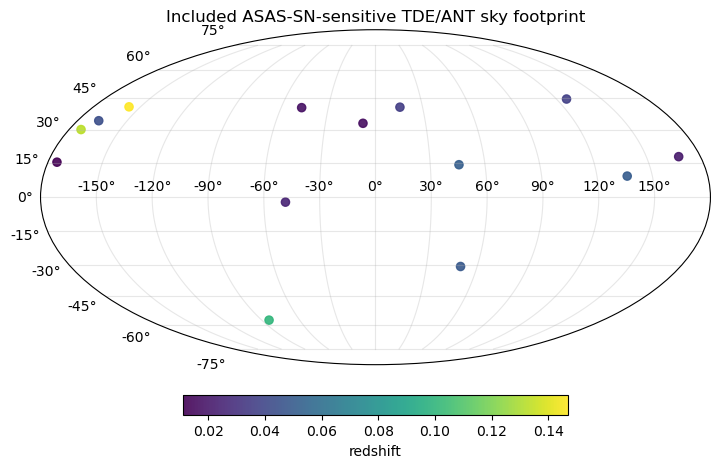

In [18]:
sky_sample = included_science.dropna(subset=["ra_deg", "dec_deg"]).copy()
ra_rad = np.deg2rad(-((sky_sample["ra_deg"] + 180) % 360 - 180))
dec_rad = np.deg2rad(sky_sample["dec_deg"])

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection="mollweide")
ax.scatter(ra_rad, dec_rad, s=35, c=sky_sample["redshift"], cmap="viridis", alpha=0.9)
ax.grid(alpha=0.3)
ax.set_title("Included ASAS-SN-sensitive TDE/ANT sky footprint")
cbar = fig.colorbar(ax.collections[0], ax=ax, orientation="horizontal", pad=0.08, fraction=0.05)
cbar.set_label("redshift")
plt.show()


## Rise/Fallback Readiness

For the next phase, the useful rows are bright included objects with redshift, coordinates, and either a catalog peak MJD or enough provenance to retrieve light curves. This table ranks the current catalog for follow-up light-curve fitting.


In [19]:
def readiness_score(row: pd.Series) -> int:
    score = 0
    if row["class_label"] == "tde":
        score += 3
    if row["confidence"] in {"secure", "likely"}:
        score += 2
    if np.isfinite(row["redshift"]):
        score += 2
    if np.isfinite(row["peak_mjd_ref"]):
        score += 2
    if np.isfinite(row["mag_value"]) and row["mag_value"] <= 17.0:
        score += 1
    return score


def science_flags(row: pd.Series) -> str:
    flags = []
    if row["class_label"] != "tde":
        flags.append("classification review")
    if row["confidence"] not in {"secure", "likely"}:
        flags.append("low-confidence label")
    if not np.isfinite(row["redshift"]):
        flags.append("missing redshift")
    if not np.isfinite(row["peak_mjd_ref"]):
        flags.append("needs peak epoch")
    if not np.isfinite(row["mag_value"]):
        flags.append("missing optical mag")
    return "; ".join(flags)


science_targets = included_science.copy()
science_targets["readiness_score"] = science_targets.apply(readiness_score, axis=1)
science_targets["science_flags"] = science_targets.apply(science_flags, axis=1)

target_columns = [
    "name",
    "aliases",
    "readiness_score",
    "science_flags",
    "redshift",
    "mag_value",
    "mag_band",
    "abs_mag_proxy",
    "discovery_mjd",
    "peak_mjd_ref",
    "class_label",
    "confidence",
    "mag_basis",
]

science_targets[target_columns].sort_values(["readiness_score", "mag_value"], ascending=[False, True])


,name,aliases,readiness_score,science_flags,redshift,mag_value,mag_band,abs_mag_proxy,discovery_mjd,peak_mjd_ref,class_label,confidence,mag_basis
18,AT 2023clx,AT 2023clx;ZTF18aabkvpi;ASASSN-23bd;AT 20203clx,10,,0.011070,15.370,g,-18.027829,59997.21000,60001.000000,tde,secure,OTTER optical photometry (2024A&A...689A.350C)
2,ASASSN-15oi,ASASSN-15oi,10,,0.048400,15.974,v,-20.687462,57248.00000,57248.158280,tde,secure,OTTER optical photometry (2024arXiv240719019H)
1,ASASSN-14li,ASASSN-14li,10,,0.020600,16.668,V,-18.094095,56983.00000,56989.462997,tde,secure,OTTER optical photometry (2016MNRAS.455.2918H)
0,ASASSN-14ae,ASASSN-14ae;iPTF14aiv,10,,0.043671,16.928,V,-19.502761,56682.00000,56684.916516,tde,secure,OTTER optical photometry (2014MNRAS.445.3263H)
6,AT 2019dsg,AT 2019dsg;ATLAS19klx;ZTF19aapreis;BranStark,9,,0.051200,17.060,ASAS-SN V/g,-19.727965,58582.00000,58603.866000,tde,secure,OTTER optical photometry
3,AT 2016fnl,AT 2016fnl;iPTF 16fnl,9,,0.016300,17.170,g,-17.076655,57626.00000,57629.450200,tde,secure,OTTER optical photometry (2017ApJ...844...46B)
14,AT 2021ehb,AT 2021ehb;ATLAS21jdy;ZTF21aanxhjv;BoKatan,9,,0.017000,17.421,ztf.r,-16.918111,59274.14309,59310.958333,tde,secure,OTTER optical photometry (2023ApJS..266....9A)
25,CSS100217,CSS100217;CSS100217:102913+404220,8,needs peak epoch,0.147000,16.260,r,-22.958021,52639.00000,NaN,tde,secure,OTTER optical photometry (2011ApJ...735..106D)
5,AT 2018dyk,AT 2018dyk;ZTF18aajupnt;WTP18aamced,8,needs peak epoch,0.036720,16.720,r,-19.323281,58269.31000,NaN,tde,secure,OTTER optical photometry (2022ApJ...933..196H)
20,AT 2023lli,AT 2023lli,7,needs peak epoch,0.036000,17.273,g,-18.726132,60118.09300,NaN,tde,secure,OTTER optical photometry (2024ApJ...964L..22H)


In [20]:
manual_review_queue = science_targets.loc[science_targets["science_flags"].ne("")].copy()
manual_review_queue[target_columns].sort_values(["science_flags", "mag_value"], na_position="last")


,name,aliases,readiness_score,science_flags,redshift,mag_value,mag_band,abs_mag_proxy,discovery_mjd,peak_mjd_ref,class_label,confidence,mag_basis
15,AT 2021hfu,AT 2021hfu;ASASSN-21ek,1,classification review; low-confidence label; m...,NaN,15.680,ASAS-SN V/g,NaN,59302.160,NaN,possible_tde,possible,ASAS-SN v_g_mag
17,AT 2021ncq,AT 2021ncq;ASASSN-21iu,1,classification review; low-confidence label; m...,NaN,16.360,ASAS-SN V/g,NaN,59357.150,NaN,possible_tde,possible,ASAS-SN v_g_mag
13,AT 2020ybf,AT 2020ybf;ASASSN-20nh,1,classification review; low-confidence label; m...,NaN,16.780,ASAS-SN V/g,NaN,59142.290,NaN,possible_tde,possible,ASAS-SN v_g_mag
7,AT 2019von,AT 2019von;ASASSN-19abt,1,classification review; low-confidence label; m...,NaN,16.820,ASAS-SN V/g,NaN,58808.270,NaN,possible_tde,possible,ASAS-SN v_g_mag
11,AT 2020svp,AT 2020svp;ASASSN-20lk,3,classification review; missing redshift; needs...,NaN,15.600,ASAS-SN V/g,NaN,59100.720,NaN,tde_candidate,likely,ASAS-SN v_g_mag
9,AT 2020pom,AT 2020pom;ASASSN-20il,3,classification review; missing redshift; needs...,NaN,15.800,ASAS-SN V/g,NaN,59038.180,NaN,tde_candidate,likely,ASAS-SN v_g_mag
24,AT 2024kbl,AT 2024kbl;ASASSN-24dm,3,classification review; missing redshift; needs...,NaN,16.540,ASAS-SN V/g,NaN,60462.340,NaN,tde_candidate,likely,ASAS-SN v_g_mag
10,AT 2020ral,AT 2020ral;ASASSN-20jr,3,classification review; missing redshift; needs...,NaN,16.550,ASAS-SN V/g,NaN,59071.240,NaN,tde_candidate,likely,ASAS-SN v_g_mag
21,AT 2023uta,AT 2023uta;ASASSN-23hb,3,classification review; missing redshift; needs...,NaN,16.560,ASAS-SN V/g,NaN,60228.380,NaN,tde_candidate,likely,ASAS-SN v_g_mag
12,AT 2020ual,AT 2020ual;ASASSN-20mi,3,classification review; missing redshift; needs...,NaN,16.680,ASAS-SN V/g,NaN,59115.010,NaN,tde_candidate,likely,ASAS-SN v_g_mag


## Processed ASAS-SN Light-Curve Science Pipeline

This section turns the catalog into a light-curve science table. It is designed to work with already processed/fetched ASAS-SN Sky Patrol CSVs, while also providing optional gated hooks to resolve and fetch missing light curves. The measurement layer is fully inline: it reads cached CSVs, cleans them, estimates a baseline and peak epoch, then measures rise and fallback behavior in rest-frame days.

The default cells do not require network access. If no local TDE light curves are available yet, they write a manifest with missing paths and produce empty-but-schema-stable metrics tables, ready to fill once light curves are fetched or copied in.


In [21]:
# Processed-light-curve configuration.
# Keep network-backed work gated; flip these flags when you are ready to resolve/fetch ASAS-SN LCs.
TDE_LC_OUTPUT_DIR = REPO_ROOT / "malca" / "nuclear" / "output" / "tde_lightcurves"
TDE_LC_DIR = TDE_LC_OUTPUT_DIR / "skypatrol"
TDE_LC_MANIFEST_PATH = TDE_LC_OUTPUT_DIR / "tde_lc_manifest.csv"
TDE_LC_METRICS_PATH = TDE_LC_OUTPUT_DIR / "tde_lc_metrics.csv"
TDE_RISE_FALLBACK_PATH = TDE_LC_OUTPUT_DIR / "tde_rise_fallback_metrics.csv"

# Extra directories are scanned for already fetched Sky Patrol CSVs.
TDE_LC_SEARCH_DIRS = [
    TDE_LC_DIR,
    REPO_ROOT / "malca" / "nuclear" / "output" / "cache" / "lightcurves" / "skypatrol",
    REPO_ROOT / "output" / "runs" / "nuclear_stochastic_real_agn" / "lightcurves",
]

RUN_TDE_LC_RESOLUTION = False
RUN_TDE_LC_FETCH = False
RUN_TDE_LC_PROCESSING = True
REFRESH_TDE_LC_CACHE = False
MAX_TDE_LC_OBJECTS = None
SKYPATROL_RADIUS_ARCSEC = 5.0
SKYPATROL_BACKEND = "skypatrol1"

# Science-window choices. Adjust these once you inspect coverage object by object.
BASELINE_REST_END_DAY = -60.0
EVENT_REST_WINDOW = (-150.0, 900.0)
RISE_REST_WINDOW = (-150.0, 15.0)
FALLBACK_REST_WINDOW = (10.0, 900.0)
MIN_BASELINE_POINTS = 5
MIN_FALLBACK_POINTS = 4

for path in (TDE_LC_OUTPUT_DIR, TDE_LC_DIR):
    path.mkdir(parents=True, exist_ok=True)

try:
    from IPython.display import display, Markdown
except Exception:
    def display(value):
        print(value)
    def Markdown(value):
        return value


### Light-Curve Manifest

The manifest is the bridge between the catalog and processed/fetched light curves. You can hand-edit `lc_path`, `asassn_source_id`, or `lc_fetch_status` in the CSV if you already know where a light curve lives. The notebook will preserve those edits on reload.


In [22]:
def lc_token(value: object) -> str:
    text = _clean_text(value).lower()
    text = re.sub(r"[^a-z0-9]+", "", text)
    return text


def alias_tokens_for_lc(row: pd.Series) -> list[str]:
    values = [row.get("tde_id"), row.get("name"), *split_aliases(row.get("aliases"))]
    tokens = []
    for value in values:
        token = lc_token(value)
        if token and token not in tokens:
            tokens.append(token)
    return tokens


def discover_existing_lightcurves(targets: pd.DataFrame, search_dirs: list[Path]) -> dict[str, str]:
    files = []
    for directory in search_dirs:
        directory = Path(directory)
        if directory.exists():
            files.extend(sorted(directory.glob("*.csv")))
    file_tokens = [(path, lc_token(path.stem)) for path in files]
    matches: dict[str, str] = {}
    for _, row in targets.iterrows():
        tde_id = _clean_text(row.get("tde_id"))
        if not tde_id:
            continue
        tokens = alias_tokens_for_lc(row)
        for path, stem_token in file_tokens:
            if any(token and token in stem_token for token in tokens):
                matches[tde_id] = str(path)
                break
    return matches


def base_tde_lc_manifest(targets: pd.DataFrame) -> pd.DataFrame:
    columns = [
        "tde_id",
        "name",
        "aliases",
        "ra_deg",
        "dec_deg",
        "redshift",
        "discovery_mjd",
        "peak_mjd_ref",
        "class_label",
        "confidence",
        "asassn_source_id",
        "asassn_sep_arcsec",
        "asassn_mean_mag",
        "lc_path",
        "lc_fetch_status",
        "lc_fetch_error",
    ]
    out = targets.copy()
    for col in columns:
        if col not in out.columns:
            out[col] = ""
    out = out[columns].copy()
    out["lc_fetch_status"] = out["lc_fetch_status"].replace("", "unresolved")
    return out


def build_or_load_tde_lc_manifest(targets: pd.DataFrame, manifest_path: Path = TDE_LC_MANIFEST_PATH) -> pd.DataFrame:
    base = base_tde_lc_manifest(targets)
    if manifest_path.exists():
        existing = pd.read_csv(manifest_path)
        merge_cols = [col for col in existing.columns if col not in base.columns or col in {"tde_id", "asassn_source_id", "asassn_sep_arcsec", "asassn_mean_mag", "lc_path", "lc_fetch_status", "lc_fetch_error"}]
        existing = existing[[col for col in merge_cols if col in existing.columns]].copy()
        base = base.drop(columns=[col for col in existing.columns if col in base.columns and col != "tde_id"]).merge(existing, on="tde_id", how="left")
        for col in ["asassn_source_id", "asassn_sep_arcsec", "asassn_mean_mag", "lc_path", "lc_fetch_status", "lc_fetch_error"]:
            if col not in base.columns:
                base[col] = ""
    discovered = discover_existing_lightcurves(base, TDE_LC_SEARCH_DIRS)
    for idx, row in base.iterrows():
        tde_id = _clean_text(row.get("tde_id"))
        current = _clean_text(row.get("lc_path"))
        if not current and tde_id in discovered:
            base.at[idx, "lc_path"] = discovered[tde_id]
            base.at[idx, "lc_fetch_status"] = "local_discovered"
    manifest_path.parent.mkdir(parents=True, exist_ok=True)
    base.to_csv(manifest_path, index=False)
    return base


def resolve_tde_sources_with_optional_fetch_helpers(manifest: pd.DataFrame) -> pd.DataFrame:
    if not RUN_TDE_LC_RESOLUTION:
        return manifest.copy()
    try:
        from malca.fetch import cone_search
    except Exception as exc:
        out = manifest.copy()
        out["lc_fetch_status"] = out.get("lc_fetch_status", "").replace("", "resolve_helper_unavailable")
        out["lc_fetch_error"] = f"malca.fetch import failed: {type(exc).__name__}: {exc}"
        return out
    rows = []
    work = manifest.head(MAX_TDE_LC_OBJECTS).copy() if MAX_TDE_LC_OBJECTS else manifest.copy()
    for i, row in work.iterrows():
        result = row.to_dict()
        try:
            matches = cone_search(float(row["ra_deg"]), float(row["dec_deg"]), radius_arcsec=SKYPATROL_RADIUS_ARCSEC, backend=SKYPATROL_BACKEND)
            if matches.empty:
                result.update(lc_fetch_status="no_skypatrol_match", lc_fetch_error="")
            else:
                sep_col = "sp1_sep_arcsec" if "sp1_sep_arcsec" in matches.columns else "sep_arcsec"
                if sep_col in matches.columns:
                    matches = matches.sort_values(sep_col)
                best = matches.iloc[0]
                source_id = _clean_text(best.get("asas_sn_id") or best.get("source_id"))
                result.update(
                    asassn_source_id=source_id,
                    asassn_sep_arcsec=_safe_float(best.get(sep_col)),
                    asassn_mean_mag=_safe_float(best.get("mean_vmag")),
                    lc_fetch_status="resolved",
                    lc_fetch_error="",
                )
        except Exception as exc:
            result.update(lc_fetch_status="resolve_failed", lc_fetch_error=f"{type(exc).__name__}: {exc}")
        rows.append(result)
    out = pd.DataFrame(rows)
    return out


def fetch_resolved_tde_lightcurves(manifest: pd.DataFrame) -> pd.DataFrame:
    if not RUN_TDE_LC_FETCH:
        return manifest.copy()
    try:
        from malca.fetch import download_lightcurve_by_id
    except Exception as exc:
        out = manifest.copy()
        out["lc_fetch_status"] = "fetch_helper_unavailable"
        out["lc_fetch_error"] = f"malca.fetch import failed: {type(exc).__name__}: {exc}"
        return out
    out = manifest.copy()
    work_idx = list(out.head(MAX_TDE_LC_OBJECTS).index) if MAX_TDE_LC_OBJECTS else list(out.index)
    for idx in work_idx:
        source_id = _clean_text(out.at[idx, "asassn_source_id"] if "asassn_source_id" in out.columns else "")
        if not source_id:
            if not _clean_text(out.at[idx, "lc_path"] if "lc_path" in out.columns else ""):
                out.at[idx, "lc_fetch_status"] = "no_asassn_source_id"
            continue
        try:
            path, meta = download_lightcurve_by_id(source_id, cache_dir=TDE_LC_DIR, backend=SKYPATROL_BACKEND, refresh_cache=REFRESH_TDE_LC_CACHE)
            out.at[idx, "lc_path"] = str(path)
            out.at[idx, "lc_fetch_status"] = "ok"
            out.at[idx, "lc_fetch_error"] = ""
        except Exception as exc:
            out.at[idx, "lc_fetch_status"] = "fetch_failed"
            out.at[idx, "lc_fetch_error"] = f"{type(exc).__name__}: {exc}"
    return out


### Cleaning And Per-Light-Curve Metrics

The cleaner keeps good-quality Sky Patrol rows, normalizes column names, and preserves both flux and magnitude. The science measurement uses flux space whenever possible because ASAS-SN forced-photometry flux is closer to additive for baseline subtraction.


In [23]:
TDE_LC_METRIC_COLUMNS = [
    "tde_id", "name", "lc_process_status", "lc_process_error", "lc_path", "primary_band",
    "lc_n_points", "lc_n_good", "lc_n_bands", "lc_jd_start", "lc_jd_end", "lc_span_days",
    "peak_mjd_used", "peak_source", "redshift", "baseline_flux", "baseline_n", "baseline_method",
    "peak_flux", "peak_excess_flux", "peak_mag", "event_n", "rise_n", "fallback_n",
    "rise_time_half_rest", "rise_slope_flux_per_day", "fallback_alpha", "fallback_alpha_r2",
    "fallback_tau_exp_rest", "fallback_t_half_rest", "fallback_t_1mag_rest", "quality_flag",
]


def read_skypatrol_lightcurve(path: str | Path) -> pd.DataFrame:
    df = pd.read_csv(Path(path), comment="#")
    rename = {
        "JD": "jd",
        "Flux": "flux",
        "Flux Error": "flux_err",
        "Mag": "mag",
        "Mag Error": "mag_err",
        "Limit": "limit",
        "FWHM": "fwhm",
        "Filter": "band",
        "Quality": "quality",
        "Camera": "camera",
    }
    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns}).copy()
    for col in ("jd", "flux", "flux_err", "mag", "mag_err", "limit", "fwhm"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    if "band" not in df.columns:
        df["band"] = "unknown"
    if "quality" not in df.columns:
        df["quality"] = "G"
    df["source_path"] = str(path)
    return df


def clean_asassn_lightcurve(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty or "jd" not in df.columns:
        return pd.DataFrame(columns=["jd", "mjd", "flux", "flux_err", "mag", "mag_err", "band", "quality", "camera", "source_path"])
    out = df[pd.to_numeric(df["jd"], errors="coerce").notna()].copy()
    if "quality" in out.columns:
        out = out[out["quality"].astype(str).str.upper().isin(["G", "GOOD", "1", "TRUE"])].copy()
    if "flux" in out.columns:
        out = out[np.isfinite(out["flux"])].copy()
    if "flux_err" in out.columns:
        out = out[(out["flux_err"].isna()) | (out["flux_err"] > 0)].copy()
    if "mag" in out.columns:
        out.loc[~np.isfinite(out["mag"]), "mag"] = np.nan
    out["mjd"] = pd.to_numeric(out["jd"], errors="coerce") - 2400000.5
    return out.sort_values("jd").reset_index(drop=True)


def choose_primary_band(clean: pd.DataFrame, peak_mjd: float | None = None) -> str:
    if clean.empty or "band" not in clean.columns:
        return ""
    work = clean.copy()
    if peak_mjd is not None and np.isfinite(peak_mjd):
        dt = work["mjd"] - float(peak_mjd)
        event = work[(dt >= EVENT_REST_WINDOW[0]) & (dt <= EVENT_REST_WINDOW[1])]
        if len(event) >= 5:
            work = event
    counts = work.groupby(work["band"].astype(str))["mjd"].count().sort_values(ascending=False)
    return _clean_text(counts.index[0]) if len(counts) else ""


def robust_line_fit(x: np.ndarray, y: np.ndarray) -> tuple[float, float, float]:
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3 or np.nanmax(x[mask]) <= np.nanmin(x[mask]):
        return np.nan, np.nan, np.nan
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    pred = slope * x[mask] + intercept
    ss_res = float(np.sum((y[mask] - pred) ** 2))
    ss_tot = float(np.sum((y[mask] - np.nanmean(y[mask])) ** 2))
    r2 = np.nan if ss_tot <= 0 else 1.0 - ss_res / ss_tot
    return float(slope), float(intercept), float(r2)


def crossing_time(x: np.ndarray, y: np.ndarray, level: float, *, side: str) -> float:
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 2:
        return np.nan
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    if side == "rise":
        keep = x <= 0
        x = x[keep]
        y = y[keep]
    elif side == "fallback":
        keep = x >= 0
        x = x[keep]
        y = y[keep]
    if len(x) < 2:
        return np.nan
    diff = y - level
    crossings = np.where(np.signbit(diff[:-1]) != np.signbit(diff[1:]))[0]
    if len(crossings) == 0:
        return np.nan
    idx = crossings[-1] if side == "rise" else crossings[0]
    x0, x1 = x[idx], x[idx + 1]
    y0, y1 = y[idx], y[idx + 1]
    if y1 == y0:
        return float(x0)
    return float(x0 + (level - y0) * (x1 - x0) / (y1 - y0))


def estimate_peak_mjd(clean: pd.DataFrame, row: pd.Series) -> tuple[float, str]:
    catalog_peak = _safe_float(row.get("peak_mjd_ref"))
    if np.isfinite(catalog_peak):
        return float(catalog_peak), "catalog_peak_mjd_ref"
    discovery = _safe_float(row.get("discovery_mjd"))
    work = clean.copy()
    if np.isfinite(discovery):
        window = work[(work["mjd"] >= discovery - 120) & (work["mjd"] <= discovery + 240)]
        if len(window) >= 3:
            work = window
    if "flux" in work.columns and work["flux"].notna().any():
        idx = work["flux"].idxmax()
        return float(work.loc[idx, "mjd"]), "max_flux"
    if "mag" in work.columns and work["mag"].notna().any():
        idx = work["mag"].idxmin()
        return float(work.loc[idx, "mjd"]), "min_mag"
    return np.nan, "missing"


def measure_tde_lightcurve(row: pd.Series, clean: pd.DataFrame) -> dict:
    result = {col: np.nan for col in TDE_LC_METRIC_COLUMNS}
    result.update(
        tde_id=_clean_text(row.get("tde_id")),
        name=_clean_text(row.get("name")),
        lc_path=_clean_text(row.get("lc_path")),
        redshift=_safe_float(row.get("redshift")),
        lc_process_status="ok",
        lc_process_error="",
    )
    if clean.empty:
        result.update(lc_process_status="empty_clean_lc", quality_flag="no_clean_points")
        return result

    peak_mjd, peak_source = estimate_peak_mjd(clean, row)
    band = choose_primary_band(clean, peak_mjd)
    work = clean[clean["band"].astype(str) == band].copy() if band else clean.copy()
    if len(work) < 3:
        result.update(lc_process_status="too_few_band_points", primary_band=band, quality_flag="too_few_points")
        return result

    redshift = result["redshift"] if np.isfinite(result["redshift"]) and result["redshift"] > 0 else 0.0
    rest_dt = (work["mjd"].to_numpy(dtype=float) - peak_mjd) / (1.0 + redshift) if np.isfinite(peak_mjd) else np.full(len(work), np.nan)
    flux = work["flux"].to_numpy(dtype=float) if "flux" in work.columns else np.full(len(work), np.nan)
    flux_err = work["flux_err"].to_numpy(dtype=float) if "flux_err" in work.columns else np.full(len(work), np.nan)
    mag = work["mag"].to_numpy(dtype=float) if "mag" in work.columns else np.full(len(work), np.nan)

    baseline_mask = np.isfinite(rest_dt) & (rest_dt <= BASELINE_REST_END_DAY) & np.isfinite(flux)
    baseline_method = "pre_event_median"
    if baseline_mask.sum() >= MIN_BASELINE_POINTS:
        baseline_flux = float(np.nanmedian(flux[baseline_mask]))
    else:
        finite_flux = flux[np.isfinite(flux)]
        baseline_flux = float(np.nanpercentile(finite_flux, 20)) if len(finite_flux) else np.nan
        baseline_method = "global_p20_flux"
    excess = flux - baseline_flux if np.isfinite(baseline_flux) else np.full(len(work), np.nan)

    event_mask = np.isfinite(rest_dt) & (rest_dt >= EVENT_REST_WINDOW[0]) & (rest_dt <= EVENT_REST_WINDOW[1])
    if event_mask.any() and np.isfinite(excess[event_mask]).any():
        event_indices = np.where(event_mask)[0]
        peak_idx = event_indices[np.nanargmax(excess[event_mask])]
    elif np.isfinite(excess).any():
        peak_idx = int(np.nanargmax(excess))
    else:
        peak_idx = 0

    peak_flux = float(flux[peak_idx]) if np.isfinite(flux[peak_idx]) else np.nan
    peak_excess = float(excess[peak_idx]) if np.isfinite(excess[peak_idx]) else np.nan
    peak_mag = float(mag[peak_idx]) if np.isfinite(mag[peak_idx]) else np.nan

    rise_mask = np.isfinite(rest_dt) & (rest_dt >= RISE_REST_WINDOW[0]) & (rest_dt <= RISE_REST_WINDOW[1]) & np.isfinite(excess)
    fallback_mask = np.isfinite(rest_dt) & (rest_dt >= FALLBACK_REST_WINDOW[0]) & (rest_dt <= FALLBACK_REST_WINDOW[1]) & np.isfinite(excess)
    if np.isfinite(peak_excess) and peak_excess > 0:
        fallback_mask &= excess > max(0.05 * peak_excess, 0.0)
        if np.isfinite(flux_err).any():
            fallback_mask &= (np.isnan(flux_err) | (excess > 2.0 * flux_err))

    rise_slope, _, _ = robust_line_fit(rest_dt[rise_mask], excess[rise_mask])
    rise_half = np.nan
    fallback_half = np.nan
    fallback_1mag = np.nan
    if np.isfinite(peak_excess) and peak_excess > 0:
        half_time = crossing_time(rest_dt, excess, 0.5 * peak_excess, side="rise")
        rise_half = -half_time if np.isfinite(half_time) else np.nan
        fallback_half = crossing_time(rest_dt, excess, 0.5 * peak_excess, side="fallback")
        fallback_1mag = crossing_time(rest_dt, excess, peak_excess / 2.5118864315, side="fallback")

    alpha = np.nan
    alpha_r2 = np.nan
    tau_exp = np.nan
    if fallback_mask.sum() >= MIN_FALLBACK_POINTS and np.isfinite(peak_excess) and peak_excess > 0:
        t_fb = rest_dt[fallback_mask]
        y_fb = excess[fallback_mask]
        valid = np.isfinite(t_fb) & np.isfinite(y_fb) & (t_fb > 0) & (y_fb > 0)
        if valid.sum() >= MIN_FALLBACK_POINTS:
            alpha, intercept, alpha_r2 = robust_line_fit(np.log10(t_fb[valid] / 30.0), np.log10(y_fb[valid] / peak_excess))
            exp_slope, exp_intercept, exp_r2 = robust_line_fit(t_fb[valid], np.log(y_fb[valid] / peak_excess))
            if np.isfinite(exp_slope) and exp_slope < 0:
                tau_exp = float(-1.0 / exp_slope)

    flags = []
    if not np.isfinite(peak_mjd):
        flags.append("missing_peak")
    if baseline_mask.sum() < MIN_BASELINE_POINTS:
        flags.append("weak_pre_event_baseline")
    if fallback_mask.sum() < MIN_FALLBACK_POINTS:
        flags.append("weak_fallback_sampling")
    if not np.isfinite(alpha):
        flags.append("no_powerlaw_fit")

    result.update(
        primary_band=band,
        lc_n_points=int(len(clean)),
        lc_n_good=int(len(work)),
        lc_n_bands=int(clean["band"].nunique()) if "band" in clean.columns else 0,
        lc_jd_start=float(work["jd"].min()),
        lc_jd_end=float(work["jd"].max()),
        lc_span_days=float(work["jd"].max() - work["jd"].min()),
        peak_mjd_used=float(peak_mjd) if np.isfinite(peak_mjd) else np.nan,
        peak_source=peak_source,
        baseline_flux=baseline_flux,
        baseline_n=int(baseline_mask.sum()),
        baseline_method=baseline_method,
        peak_flux=peak_flux,
        peak_excess_flux=peak_excess,
        peak_mag=peak_mag,
        event_n=int(event_mask.sum()),
        rise_n=int(rise_mask.sum()),
        fallback_n=int(fallback_mask.sum()),
        rise_time_half_rest=rise_half,
        rise_slope_flux_per_day=rise_slope,
        fallback_alpha=alpha,
        fallback_alpha_r2=alpha_r2,
        fallback_tau_exp_rest=tau_exp,
        fallback_t_half_rest=fallback_half,
        fallback_t_1mag_rest=fallback_1mag,
        quality_flag="; ".join(flags) if flags else "ok",
    )
    return result


def process_tde_lightcurve_manifest(manifest: pd.DataFrame) -> pd.DataFrame:
    rows = []
    work = manifest.head(MAX_TDE_LC_OBJECTS).copy() if MAX_TDE_LC_OBJECTS else manifest.copy()
    for _, row in work.iterrows():
        path = Path(_clean_text(row.get("lc_path")))
        if not _clean_text(path) or not path.exists():
            result = {col: np.nan for col in TDE_LC_METRIC_COLUMNS}
            result.update(
                tde_id=_clean_text(row.get("tde_id")),
                name=_clean_text(row.get("name")),
                lc_path=_clean_text(row.get("lc_path")),
                redshift=_safe_float(row.get("redshift")),
                lc_process_status="missing_lc_path",
                lc_process_error="",
                quality_flag="missing_lc_path",
            )
            rows.append(result)
            continue
        try:
            clean = clean_asassn_lightcurve(read_skypatrol_lightcurve(path))
            rows.append(measure_tde_lightcurve(row, clean))
        except Exception as exc:
            result = {col: np.nan for col in TDE_LC_METRIC_COLUMNS}
            result.update(
                tde_id=_clean_text(row.get("tde_id")),
                name=_clean_text(row.get("name")),
                lc_path=str(path),
                redshift=_safe_float(row.get("redshift")),
                lc_process_status="process_failed",
                lc_process_error=f"{type(exc).__name__}: {exc}",
                quality_flag="process_failed",
            )
            rows.append(result)
    out = pd.DataFrame(rows, columns=TDE_LC_METRIC_COLUMNS)
    return out


### Run The Processed-LC Pipeline

This cell builds or reloads the light-curve manifest, optionally resolves/fetches ASAS-SN source IDs, processes any available CSVs, and writes the science metrics.


In [24]:
tde_lc_manifest = build_or_load_tde_lc_manifest(science_targets, TDE_LC_MANIFEST_PATH)

if RUN_TDE_LC_RESOLUTION:
    tde_lc_manifest = resolve_tde_sources_with_optional_fetch_helpers(tde_lc_manifest)
    tde_lc_manifest.to_csv(TDE_LC_MANIFEST_PATH, index=False)

if RUN_TDE_LC_FETCH:
    tde_lc_manifest = fetch_resolved_tde_lightcurves(tde_lc_manifest)
    tde_lc_manifest.to_csv(TDE_LC_MANIFEST_PATH, index=False)

if RUN_TDE_LC_PROCESSING:
    tde_lc_metrics = process_tde_lightcurve_manifest(tde_lc_manifest)
    tde_lc_metrics.to_csv(TDE_LC_METRICS_PATH, index=False)
elif TDE_LC_METRICS_PATH.exists():
    tde_lc_metrics = pd.read_csv(TDE_LC_METRICS_PATH)
else:
    tde_lc_metrics = pd.DataFrame(columns=TDE_LC_METRIC_COLUMNS)

tde_rise_fallback = science_targets.merge(
    tde_lc_metrics,
    on=["tde_id", "name", "redshift"],
    how="left",
    suffixes=("", "_lc"),
)
tde_rise_fallback.to_csv(TDE_RISE_FALLBACK_PATH, index=False)

lc_summary = pd.DataFrame(
    [
        ("manifest rows", len(tde_lc_manifest)),
        ("manifest rows with lc_path", int(tde_lc_manifest["lc_path"].astype(str).str.strip().ne("").sum()) if "lc_path" in tde_lc_manifest.columns else 0),
        ("processed rows", len(tde_lc_metrics)),
        ("processed ok", int((tde_lc_metrics["lc_process_status"] == "ok").sum()) if "lc_process_status" in tde_lc_metrics.columns else 0),
        ("fallback power-law fits", int(tde_lc_metrics["fallback_alpha"].notna().sum()) if "fallback_alpha" in tde_lc_metrics.columns else 0),
    ],
    columns=["quantity", "value"],
)

display(Markdown(f"Wrote manifest to `{TDE_LC_MANIFEST_PATH}` and metrics to `{TDE_LC_METRICS_PATH}`."))
lc_summary


Wrote manifest to `/Users/calder/code/malca/malca/nuclear/output/tde_lightcurves/tde_lc_manifest.csv` and metrics to `/Users/calder/code/malca/malca/nuclear/output/tde_lightcurves/tde_lc_metrics.csv`.

,quantity,value
0,manifest rows,26
1,manifest rows with lc_path,0
2,processed rows,26
3,processed ok,0
4,fallback power-law fits,0


### Inspect Rise/Fallback Metrics

Rows with `lc_process_status == "ok"` have measured light-curve features. Rows with `missing_lc_path` are waiting for a cached/fetched Sky Patrol CSV path in the manifest.


In [25]:
metric_view_columns = [
    "name", "class_label", "confidence", "lc_process_status", "quality_flag", "primary_band",
    "lc_n_good", "baseline_n", "peak_mjd_used", "peak_excess_flux",
    "rise_time_half_rest", "fallback_alpha", "fallback_alpha_r2",
    "fallback_tau_exp_rest", "fallback_t_half_rest", "fallback_t_1mag_rest", "lc_path",
]

for col in metric_view_columns:
    if col not in tde_rise_fallback.columns:
        tde_rise_fallback[col] = np.nan

tde_rise_fallback[metric_view_columns].sort_values(["lc_process_status", "quality_flag", "name"], na_position="last")


,name,class_label,confidence,lc_process_status,quality_flag,primary_band,lc_n_good,baseline_n,peak_mjd_used,peak_excess_flux,rise_time_half_rest,fallback_alpha,fallback_alpha_r2,fallback_tau_exp_rest,fallback_t_half_rest,fallback_t_1mag_rest,lc_path
0,ASASSN-14ae,tde,secure,process_failed,process_failed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.
1,ASASSN-14li,tde,secure,process_failed,process_failed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.
2,ASASSN-15oi,tde,secure,process_failed,process_failed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.
3,AT 2016fnl,tde,secure,process_failed,process_failed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.
4,AT 2017bcc,ant,likely,process_failed,process_failed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.
5,AT 2018dyk,tde,secure,process_failed,process_failed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.
6,AT 2019dsg,tde,secure,process_failed,process_failed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.
7,AT 2019von,possible_tde,possible,process_failed,process_failed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.
8,AT 2020afhd,tde_candidate,likely,process_failed,process_failed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.
9,AT 2020pom,tde_candidate,likely,process_failed,process_failed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.


In [26]:
fit_ready = tde_rise_fallback[
    (tde_rise_fallback["lc_process_status"] == "ok")
    & tde_rise_fallback["fallback_alpha"].notna()
].copy()

if fit_ready.empty:
    display(Markdown("No fitted TDE light curves yet. Populate `lc_path` in the manifest or enable the resolve/fetch flags, then rerun the processed-LC cells."))
else:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].hist(fit_ready["fallback_alpha"].dropna(), bins=12, color="#3b7ea1", edgecolor="white")
    axes[0].axvline(-5 / 3, color="black", linestyle="--", linewidth=1, label="-5/3")
    axes[0].set_xlabel("fallback power-law alpha")
    axes[0].set_ylabel("objects")
    axes[0].legend()

    axes[1].scatter(fit_ready["rise_time_half_rest"], fit_ready["fallback_alpha"], c=fit_ready["redshift"], cmap="viridis")
    axes[1].axhline(-5 / 3, color="black", linestyle="--", linewidth=1)
    axes[1].set_xlabel("rise half-time rest days")
    axes[1].set_ylabel("fallback alpha")

    axes[2].scatter(fit_ready["peak_excess_flux"], fit_ready["fallback_tau_exp_rest"], c=fit_ready["fallback_alpha"], cmap="coolwarm")
    axes[2].set_xlabel("peak excess flux")
    axes[2].set_ylabel("exp fallback tau rest days")

    for ax in axes:
        ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

fit_ready[["name", "redshift", "primary_band", "rise_time_half_rest", "fallback_alpha", "fallback_alpha_r2", "fallback_tau_exp_rest", "quality_flag"]]


No fitted TDE light curves yet. Populate `lc_path` in the manifest or enable the resolve/fetch flags, then rerun the processed-LC cells.

,name,redshift,primary_band,rise_time_half_rest,fallback_alpha,fallback_alpha_r2,fallback_tau_exp_rest,quality_flag


### Single-Object Diagnostic Plot

Use this after a row has a valid `lc_path`. It plots flux excess versus rest-frame days, plus the fitted power-law fallback if available.


In [27]:
def plot_tde_rise_fallback_diagnostic(tde_id_or_name: str, metrics_table: pd.DataFrame = tde_rise_fallback) -> plt.Figure:
    key = lc_token(tde_id_or_name)
    mask = metrics_table["tde_id"].map(lc_token).eq(key) | metrics_table["name"].map(lc_token).eq(key)
    if not mask.any():
        alias_text = metrics_table.get("aliases", pd.Series([""] * len(metrics_table))).astype(str).map(lc_token)
        mask = alias_text.str.contains(key, na=False)
    if not mask.any():
        raise KeyError(f"No TDE row matches {tde_id_or_name!r}")
    row = metrics_table.loc[mask].iloc[0]
    path = Path(_clean_text(row.get("lc_path")))
    if not path.exists():
        raise FileNotFoundError(f"No light curve file for {row.get('name')}: {path}")

    clean = clean_asassn_lightcurve(read_skypatrol_lightcurve(path))
    band = _clean_text(row.get("primary_band")) or choose_primary_band(clean, _safe_float(row.get("peak_mjd_used")))
    work = clean[clean["band"].astype(str) == band].copy() if band else clean.copy()
    z = _safe_float(row.get("redshift"))
    z = z if np.isfinite(z) and z > 0 else 0.0
    peak_mjd = _safe_float(row.get("peak_mjd_used"))
    baseline = _safe_float(row.get("baseline_flux"))
    rest_dt = (work["mjd"] - peak_mjd) / (1 + z)
    excess = work["flux"] - baseline

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.errorbar(rest_dt, excess, yerr=work.get("flux_err"), fmt="o", ms=4, alpha=0.75, label=f"{band or 'all bands'} excess flux")
    ax.axvline(0, color="black", linewidth=1, alpha=0.5)
    ax.axhline(0, color="black", linewidth=1, alpha=0.3)

    alpha = _safe_float(row.get("fallback_alpha"))
    peak_excess = _safe_float(row.get("peak_excess_flux"))
    if np.isfinite(alpha) and np.isfinite(peak_excess) and peak_excess > 0:
        t = np.linspace(max(10, FALLBACK_REST_WINDOW[0]), FALLBACK_REST_WINDOW[1], 300)
        model = peak_excess * (t / 30.0) ** alpha
        scale_mask = (rest_dt >= FALLBACK_REST_WINDOW[0]) & (rest_dt <= FALLBACK_REST_WINDOW[1]) & (excess > 0)
        if scale_mask.sum() >= 2:
            model_at_data = peak_excess * (rest_dt[scale_mask].to_numpy(dtype=float) / 30.0) ** alpha
            scale = np.nanmedian(excess[scale_mask] / model_at_data)
            if np.isfinite(scale):
                model *= scale
        ax.plot(t, model, color="#b45f4d", linewidth=2, label=f"power-law alpha={alpha:.2f}")

    ax.set_title(f"{row.get('name')} rise/fallback diagnostic")
    ax.set_xlabel("rest-frame days from peak")
    ax.set_ylabel("ASAS-SN flux excess")
    ax.grid(alpha=0.2)
    ax.legend()
    fig.tight_layout()
    return fig

# Example after a row has lc_path populated:
# plot_tde_rise_fallback_diagnostic("ASASSN-14li")
